# Exercise 4.10 — Population Growth with an Optimal Population Size
**Sayama, *Introduction to the Modeling and Analysis of Complex Systems*, Section 4.5**

---

**Problem:** Create a mathematical model of population growth in which the growth ratio is **highest at a certain optimal population size** $x_{op}$, but decreases as the population deviates from that size. Simulate its behavior and compare it to the standard logistic growth model.

## 1. Mathematical Background — Eq. 4.21

Sayama's discrete-time population model (Eq. 4.21) writes population growth as:

$$x_{t+1} = f(x_t) \cdot x_t$$

The function $f(x)$ is the **population-dependent growth ratio**. For **logistic growth** it is a linearly decreasing function:

$$f_{\text{logistic}}(x) = -\frac{a-1}{K}\,x + a$$

- $a > 1$: growth ratio at near-zero population (maximum)
- $K$: carrying capacity — stable equilibrium where $f(K) = 1$
- $f(x)$ is **monotonically decreasing** — smallest populations always grow fastest

This means any nonzero population, no matter how tiny, will always recover to $K$. That's what we're changing.

---

## 2. Designing the New f(x) — An Inverted Parabola

We need an $f(x)$ that:
1. **Peaks at an optimal population $x_{op}$** (not at $x = 0$)
2. **Decreases symmetrically on both sides** of $x_{op}$
3. **Satisfies $f(x_{op}) > 1$** so the population can actually grow near the optimum

An inverted (upward-concave) parabola centered at $x_{op}$ does this exactly:

$$\boxed{f_{\text{parabolic}}(x) = -c\,(x - x_{op})^2 + f_{\max}}$$

where $c > 0$ controls the width of the peak and $f_{\max} = f(x_{op}) > 1$.

### Finding the Equilibria

The non-trivial fixed points of $x_{t+1} = f(x) \cdot x$ occur where $f(x) = 1$:

$$-c(x - x_{op})^2 + f_{\max} = 1 \implies x = x_{op} \pm \sqrt{\frac{f_{\max}-1}{c}}$$

This gives **two** non-zero equilibria (compared to only one for logistic):

| Equilibrium | Formula | Stability | Meaning |
|---|---|---|---|
| $x_-$ (lower) | $x_{op} - \sqrt{\frac{f_{\max}-1}{c}}$ | **Unstable** | Allee threshold — populations below this go extinct |
| $x_+$ (upper) | $x_{op} + \sqrt{\frac{f_{\max}-1}{c}}$ | **Stable** | Effective carrying capacity |

The **Allee effect** is the key structural difference from logistic growth: there is now a **minimum viable population**. If $x_t < x_-$, the population is doomed to extinction even though it is nonzero.

### Parameter Choice

We also need $f(0) < 1$ to ensure the Allee effect is active at very low densities:

$$f(0) = -c \cdot x_{op}^2 + f_{\max} < 1 \implies c > \frac{f_{\max} - 1}{x_{op}^2}$$

We use: $x_{op} = 50$, $f_{\max} = 1.2$, $c = 2 \times 10^{-4}$, which gives $f(0) = 0.7$ and a clearly visible Allee threshold.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 3. Define Both Models

The code below defines:
- `f_logistic(x)` — the standard Eq. 4.21 linear growth ratio
- `f_parabolic(x)` — the new inverted-parabola growth ratio (answers Ex. 4.10)
- Equilibria for both models, computed analytically

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL DEFINITIONS
# ─────────────────────────────────────────────────────────────────────────────

# ── Logistic baseline (Eq. 4.21) ─────────────────────────────────────────────
a = 2.0     # growth ratio at near-zero population
K = 100.0   # carrying capacity

def f_logistic(x):
    """Eq. 4.21: linearly decreasing growth ratio.
    f(0) = a  (maximum, at smallest population)
    f(K) = 1  (equilibrium at carrying capacity)
    """
    return -(a - 1.0) / K * x + a


# ── Parabolic model — Exercise 4.10 answer ────────────────────────────────────
x_op  = 50.0    # optimal population size: where growth ratio is maximised
f_max = 1.2     # maximum growth ratio, achieved exactly at x = x_op
c     = 2e-4    # curvature; larger c → narrower peak, lower Allee threshold

def f_parabolic(x):
    """Ex. 4.10: inverted-parabola growth ratio centred at x_op.

    f(x_op) = f_max > 1  →  growth is possible at optimal density.
    f(x) < 1 for x << x_op →  Allee effect: sparse populations decline.
    f(x) < 1 for x >> x_op →  overcrowding: dense populations shrink.
    """
    return -c * (x - x_op)**2 + f_max


# ── Analytical equilibria ─────────────────────────────────────────────────────
# Solve f(x) = 1  →  x = x_op ± sqrt((f_max - 1) / c)
delta           = np.sqrt((f_max - 1.0) / c)      # half-width between equilibria
allee_threshold = x_op - delta                     # x-  lower unstable threshold
upper_eq        = x_op + delta                     # x+  upper stable carrying cap

print("=== Parameter Summary ===")
print(f"\nLogistic model  (Eq. 4.21):")
print(f"  a = {a}, K = {K}")
print(f"  f(0)   = {f_logistic(0):.3f}  ← maximum growth ratio (at near-zero population)")
print(f"  f(K)   = {f_logistic(K):.3f}  ← equilibrium at carrying capacity")
print(f"  One non-zero equilibrium: x* = {K:.1f}")

print(f"\nParabolic model  (Exercise 4.10):")
print(f"  x_op = {x_op}, f_max = {f_max}, c = {c}")
print(f"  f(0)      = {f_parabolic(0):.3f}  ← < 1, confirms Allee effect at low density")
print(f"  f(x_op)   = {f_parabolic(x_op):.3f}  ← peak growth ratio at optimal population")
print(f"  Allee threshold  x-  ≈ {allee_threshold:.2f}  (unstable; populations below → extinct)")
print(f"  Upper equilibrium x+ ≈ {upper_eq:.2f}  (stable;   populations above x- → x+)")

=== Parameter Summary ===

Logistic model  (Eq. 4.21):
  a = 2.0, K = 100.0
  f(0)   = 2.000  ← maximum growth ratio (at near-zero population)
  f(K)   = 1.000  ← equilibrium at carrying capacity
  One non-zero equilibrium: x* = 100.0

Parabolic model  (Exercise 4.10):
  x_op = 50.0, f_max = 1.2, c = 0.0002
  f(0)      = 0.700  ← < 1, confirms Allee effect at low density
  f(x_op)   = 1.200  ← peak growth ratio at optimal population
  Allee threshold  x-  ≈ 18.38  (unstable; populations below → extinct)
  Upper equilibrium x+ ≈ 81.62  (stable;   populations above x- → x+)


## 4. Visualize f(x) for Both Models

This plot directly answers the question of *how the models differ structurally*. The shaded region shows where $f(x) > 1$ (net growth) for the parabolic model.

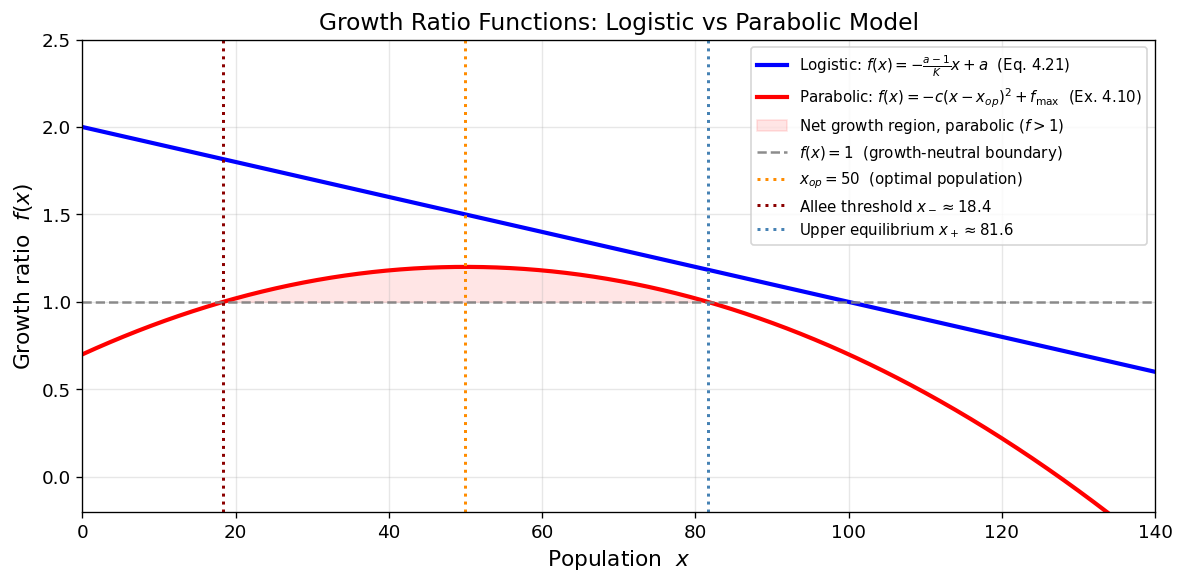

Logistic  f(x): monotone decreasing — max growth at x=0, decreases forever.
Parabolic f(x): peaks at x_op=50 — low AND high populations both have reduced growth.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Compare f(x) curves: shows the structural difference
# ─────────────────────────────────────────────────────────────────────────────

x_vals = np.linspace(0, 140, 700)
f_log_vals = f_logistic(x_vals)
f_par_vals = f_parabolic(x_vals)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_vals, f_log_vals, 'b-', lw=2.5,
        label=r'Logistic: $f(x) = -\frac{a-1}{K}x + a$  (Eq. 4.21)')
ax.plot(x_vals, f_par_vals, 'r-', lw=2.5,
        label=r'Parabolic: $f(x) = -c(x-x_{op})^2 + f_{\max}$  (Ex. 4.10)')

# Shade the growth region for the parabolic model
ax.fill_between(x_vals, 1.0, f_par_vals,
                where=(f_par_vals > 1), alpha=0.10, color='red',
                label='Net growth region, parabolic ($f > 1$)')

# Reference lines
ax.axhline(1.0,  color='gray',    linestyle='--', lw=1.5, alpha=0.9,
           label='$f(x) = 1$  (growth-neutral boundary)')
ax.axvline(x_op, color='darkorange', linestyle=':', lw=1.8,
           label=f'$x_{{op}} = {x_op:.0f}$  (optimal population)')
ax.axvline(allee_threshold, color='darkred', linestyle=':', lw=1.8,
           label=f'Allee threshold $x_- \\approx {allee_threshold:.1f}$')
ax.axvline(upper_eq, color='steelblue', linestyle=':', lw=1.8,
           label=f'Upper equilibrium $x_+ \\approx {upper_eq:.1f}$')

ax.set_xlabel('Population  $x$', fontsize=13)
ax.set_ylabel('Growth ratio  $f(x)$', fontsize=13)
ax.set_title('Growth Ratio Functions: Logistic vs Parabolic Model', fontsize=14)
ax.set_xlim(0, 140)
ax.set_ylim(-0.2, 2.5)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Logistic  f(x): monotone decreasing — max growth at x=0, decreases forever.")
print("Parabolic f(x): peaks at x_op=50 — low AND high populations both have reduced growth.")

## 5. Simulate x_{t+1} = f(x_t) · x_t

We simulate both models from two starting points:
- **$x_0 = 20$** — above the Allee threshold ($x_- \approx 18.4$)
- **$x_0 = 5$** — below the Allee threshold

The logistic model is unaffected by the starting point (both converge to $K$). The parabolic model reveals the Allee effect.

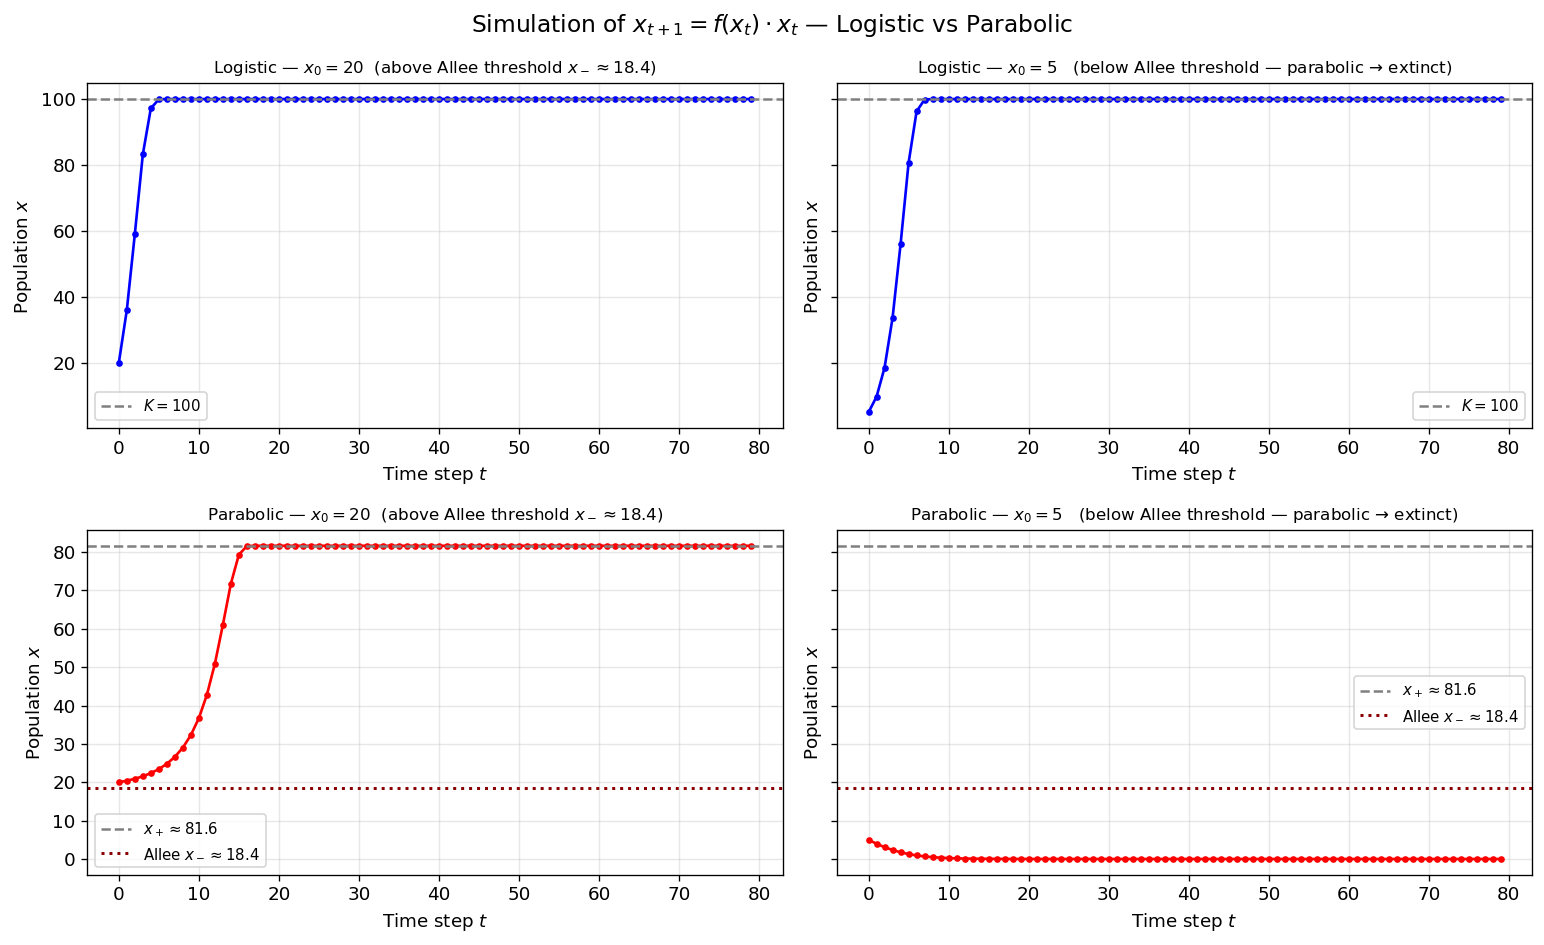

x0 = 20.0: logistic → 100.00,  parabolic → 81.62
x0 = 5.0:  logistic → 100.00,  parabolic → 0.000000  (extinct)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# SIMULATION ENGINE
# Implements x_{t+1} = f(x_t) * x_t  (Eq. 4.21 framework)
# ─────────────────────────────────────────────────────────────────────────────

def simulate(f_func, x0, steps=80):
    """Iterate x_{t+1} = f(x_t) * x_t.
    Clamps to 0 once the population goes non-positive (extinction is absorbing).
    """
    x = np.zeros(steps)
    x[0] = float(x0)
    for t in range(steps - 1):
        if x[t] <= 0.0:
            # once extinct, stays extinct
            x[t+1:] = 0.0
            break
        x[t+1] = max(0.0, f_func(x[t]) * x[t])
    return x


# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Single trajectory comparison: above vs below Allee threshold
# ─────────────────────────────────────────────────────────────────────────────

steps   = 80
t_axis  = np.arange(steps)

x0_above = 20.0   # just above Allee threshold (~18.4)
x0_below = 5.0    # clearly below Allee threshold

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey='row')
fig.suptitle(
    r'Simulation of $x_{t+1} = f(x_t)\cdot x_t$ — Logistic vs Parabolic',
    fontsize=14)

scenario_labels = [
    (x0_above, f'$x_0 = {x0_above:.0f}$  (above Allee threshold $x_-\\approx{allee_threshold:.1f}$)'),
    (x0_below, f'$x_0 = {x0_below:.0f}$   (below Allee threshold — parabolic → extinct)'),
]

for col, (x0, label) in enumerate(scenario_labels):
    x_log = simulate(f_logistic,  x0, steps)
    x_par = simulate(f_parabolic, x0, steps)

    # --- Logistic (top row) ---
    ax = axes[0, col]
    ax.plot(t_axis, x_log, 'b-o', ms=3, lw=1.6)
    ax.axhline(K, color='gray', linestyle='--', lw=1.5, label=f'$K = {K:.0f}$')
    ax.set_title(f'Logistic — {label}', fontsize=10)
    ax.set_ylabel('Population $x$')
    ax.set_xlabel('Time step $t$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Parabolic (bottom row) ---
    ax = axes[1, col]
    ax.plot(t_axis, x_par, 'r-o', ms=3, lw=1.6)
    ax.axhline(upper_eq, color='gray', linestyle='--', lw=1.5,
               label=f'$x_+ \\approx {upper_eq:.1f}$')
    ax.axhline(allee_threshold, color='darkred', linestyle=':', lw=1.8,
               label=f'Allee $x_- \\approx {allee_threshold:.1f}$')
    ax.set_title(f'Parabolic — {label}', fontsize=10)
    ax.set_ylabel('Population $x$')
    ax.set_xlabel('Time step $t$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"x0 = {x0_above}: logistic → {simulate(f_logistic, x0_above)[-1]:.2f},  "
      f"parabolic → {simulate(f_parabolic, x0_above)[-1]:.2f}")
print(f"x0 = {x0_below}:  logistic → {simulate(f_logistic, x0_below)[-1]:.2f},  "
      f"parabolic → {simulate(f_parabolic, x0_below)[-1]:.6f}  (extinct)")

## 6. Multiple Initial Conditions — Reveal the Allee Effect

Here we run **both models from many different starting points** to show the global difference in behavior. The Allee threshold acts as a separatrix in the parabolic model.

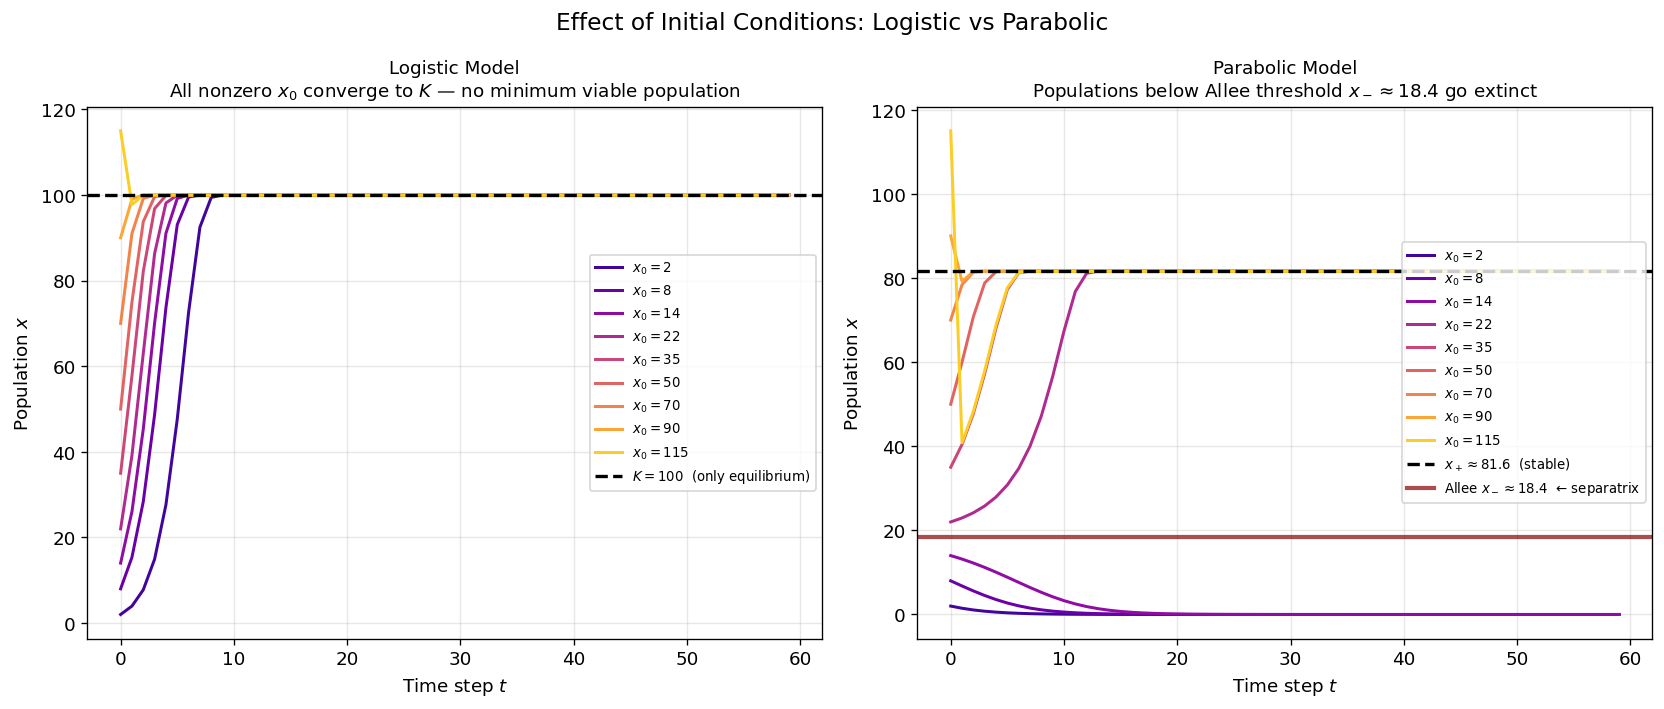

    x0 |   Logistic final |   Parabolic final | Parabolic outcome
--------------------------------------------------------------------
     2 |          100.000 |          0.000000 | → EXTINCT  ← below Allee threshold
     8 |          100.000 |          0.000000 | → EXTINCT  ← below Allee threshold
    14 |          100.000 |          0.000000 | → EXTINCT  ← below Allee threshold
    22 |          100.000 |         81.622777 | → 81.623
    35 |          100.000 |         81.622777 | → 81.623
    50 |          100.000 |         81.622777 | → 81.623
    70 |          100.000 |         81.622777 | → 81.623
    90 |          100.000 |         81.622777 | → 81.623
   115 |          100.000 |         81.622777 | → 81.623


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Multiple initial conditions
# Shows the Allee threshold as a separatrix in the parabolic model.
# In the logistic model, every positive x0 converges to K — no threshold.
# ─────────────────────────────────────────────────────────────────────────────

x0_list = [2, 8, 14, 22, 35, 50, 70, 90, 115]
cmap    = plt.cm.plasma(np.linspace(0.1, 0.9, len(x0_list)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for x0_val, col in zip(x0_list, cmap):
    x_log = simulate(f_logistic,  x0_val, 60)
    x_par = simulate(f_parabolic, x0_val, 60)
    axes[0].plot(np.arange(60), x_log, color=col, lw=1.8, label=f'$x_0={x0_val}$')
    axes[1].plot(np.arange(60), x_par, color=col, lw=1.8, label=f'$x_0={x0_val}$')

# Logistic panel
axes[0].axhline(K, color='black', linestyle='--', lw=2.0, label=f'$K = {K:.0f}$  (only equilibrium)')
axes[0].set_title('Logistic Model\nAll nonzero $x_0$ converge to $K$ — no minimum viable population', fontsize=11)
axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('Population $x$')
axes[0].legend(fontsize=8, loc='right')
axes[0].grid(True, alpha=0.3)

# Parabolic panel
axes[1].axhline(upper_eq, color='black', linestyle='--', lw=2.0,
                label=f'$x_+ \\approx {upper_eq:.1f}$  (stable)')
axes[1].axhline(allee_threshold, color='darkred', linestyle='-', lw=2.5, alpha=0.7,
                label=f'Allee $x_- \\approx {allee_threshold:.1f}$  ← separatrix')
axes[1].set_title(
    f'Parabolic Model\nPopulations below Allee threshold $x_-\\approx{allee_threshold:.1f}$ go extinct',
    fontsize=11)
axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('Population $x$')
axes[1].legend(fontsize=8, loc='right')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Effect of Initial Conditions: Logistic vs Parabolic', fontsize=14)
plt.tight_layout()
plt.show()

# ── Outcome table ──────────────────────────────────────────────────────────────
print(f"{'x0':>6} | {'Logistic final':>16} | {'Parabolic final':>17} | Parabolic outcome")
print("-" * 68)
for x0_val in x0_list:
    log_f = simulate(f_logistic,  x0_val, 300)[-1]
    par_f = simulate(f_parabolic, x0_val, 300)[-1]
    above = "→ EXTINCT" if par_f < 0.01 else f"→ {par_f:.3f}"
    allee_mark = "  ← below Allee threshold" if x0_val < allee_threshold else ""
    print(f"{x0_val:>6} | {log_f:>16.3f} | {par_f:>17.6f} | {above}{allee_mark}")

## 7. Cobweb Diagrams — Geometric Picture of the Dynamics

A **cobweb diagram** plots $g(x) = f(x) \cdot x$ against the diagonal $y = x$. Where the curve crosses the diagonal are the fixed points. The cobweb trajectory shows how iterations converge or diverge.

- Logistic: $g(x) = \left(-\frac{a-1}{K}x + a\right) x$ — a downward parabola, one non-zero crossing at $K$
- Parabolic: $g(x) = \left(-c(x-x_{op})^2 + f_{\max}\right) x$ — a cubic-like curve, **two** non-zero crossings at $x_-$ and $x_+$

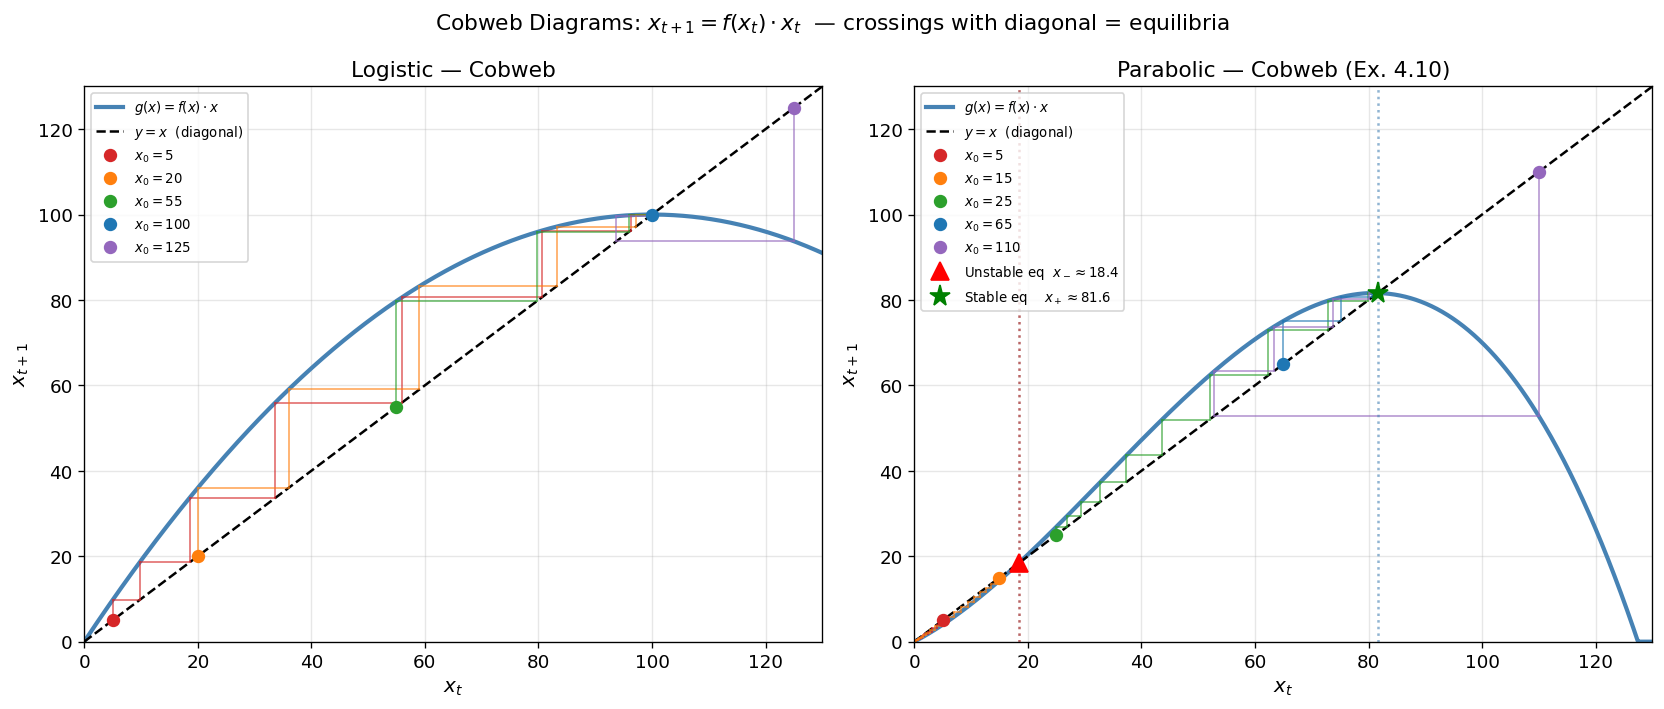

Cobweb interpretation:
  Logistic: one stable crossing at K=100. All cobwebs converge there.
  Parabolic: two non-zero crossings.
    x- ≈ 18.38 is UNSTABLE  → cobwebs starting below it spiral down to 0.
    x+ ≈ 81.62 is STABLE    → cobwebs starting above x- converge here.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Cobweb diagrams for both models
# g(x) = f(x)*x is the next-state function; crossings with y=x are equilibria.
# ─────────────────────────────────────────────────────────────────────────────

def g_logistic(x):
    """Next-state function for the logistic model."""
    return max(0.0, f_logistic(x) * x)

def g_parabolic(x):
    """Next-state function for the parabolic model."""
    return max(0.0, f_parabolic(x) * x)


def draw_cobweb(g_func, x0, ax, n_steps=50, color='crimson'):
    """Trace the cobweb starting from x0 on a pre-existing axes object."""
    x = float(x0)
    for _ in range(n_steps):
        y = g_func(x)
        # vertical segment: (x_t, x_t) → (x_t, x_{t+1})
        ax.plot([x, x], [x, y], '-', color=color, lw=0.9, alpha=0.75)
        # horizontal segment: (x_t, x_{t+1}) → (x_{t+1}, x_{t+1})
        ax.plot([x, y], [y, y], '-', color=color, lw=0.9, alpha=0.75)
        if y <= 0 or abs(y - x) < 1e-7:
            break
        x = y


x_plot    = np.linspace(0, 130, 700)
g_log_arr = np.array([g_logistic(xi)  for xi in x_plot])
g_par_arr = np.array([g_parabolic(xi) for xi in x_plot])

# Starting points: mix of below-threshold and above-threshold
starts_log = [5,  20, 55, 100, 125]   # all converge to K
starts_par = [5,  15, 25,  65, 110]   # first two are below Allee → 0
web_colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:blue', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, g_func, g_arr, starts, title in [
        (axes[0], g_logistic,  g_log_arr, starts_log, 'Logistic — Cobweb'),
        (axes[1], g_parabolic, g_par_arr, starts_par, 'Parabolic — Cobweb (Ex. 4.10)')]:

    ax.plot(x_plot, g_arr,  lw=2.5, color='steelblue',
            label=r'$g(x) = f(x)\cdot x$')
    ax.plot(x_plot, x_plot, lw=1.5, color='black', linestyle='--',
            label='$y = x$  (diagonal)')

    for x0_val, col in zip(starts, web_colors):
        draw_cobweb(g_func, x0_val, ax, n_steps=60, color=col)
        ax.plot(x0_val, x0_val, 'o', color=col, ms=7, zorder=5,
                label=f'$x_0={x0_val}$')

    ax.set_xlim(0, 130)
    ax.set_ylim(0, 130)
    ax.set_xlabel('$x_t$', fontsize=12)
    ax.set_ylabel('$x_{t+1}$', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Mark the two equilibria on the parabolic cobweb
axes[1].plot(allee_threshold, allee_threshold, 'r^', ms=11, zorder=6,
             label=f'Unstable eq  $x_- \\approx {allee_threshold:.1f}$')
axes[1].plot(upper_eq, upper_eq, 'g*', ms=13, zorder=6,
             label=f'Stable eq    $x_+ \\approx {upper_eq:.1f}$')
axes[1].axvline(allee_threshold, color='darkred',   linestyle=':', lw=1.5, alpha=0.6)
axes[1].axvline(upper_eq,        color='steelblue', linestyle=':', lw=1.5, alpha=0.6)
axes[1].legend(fontsize=8)

fig.suptitle(
    r'Cobweb Diagrams: $x_{t+1} = f(x_t)\cdot x_t$  — crossings with diagonal = equilibria',
    fontsize=13)
plt.tight_layout()
plt.show()

print("Cobweb interpretation:")
print(f"  Logistic: one stable crossing at K={K:.0f}. All cobwebs converge there.")
print(f"  Parabolic: two non-zero crossings.")
print(f"    x- ≈ {allee_threshold:.2f} is UNSTABLE  → cobwebs starting below it spiral down to 0.")
print(f"    x+ ≈ {upper_eq:.2f} is STABLE    → cobwebs starting above x- converge here.")

## 8. Summary — How the Parabolic Model Differs from Logistic Growth

| Feature | Logistic (Eq. 4.21) | Parabolic (Ex. 4.10) |
|---|---|---|
| **f(x) shape** | Monotone decreasing line | Inverted parabola, peak at $x_{op}$ |
| **Maximum growth at** | Smallest population ($x \to 0$) | Optimal density $x_{op} = 50$ |
| **Number of non-zero equilibria** | One stable: $K = 100$ | Two: unstable $x_- \approx 18.4$ + stable $x_+ \approx 81.6$ |
| **Small-population behaviour** | Always grows toward $K$ | Declines to extinction if $x < x_-$ |
| **Allee effect** | Absent | Present — minimum viable population $x_-$ |
| **Basin of attraction** | All $x_0 > 0$ → $K$ | $x_0 > x_-$ → $x_+$,  $\;$ $x_0 < x_-$ → $0$ |

### The Core Difference

The logistic model assumes that **sparsely populated environments are ideal** — the growth ratio is highest when population is lowest. This is realistic for many situations but misses a biologically important phenomenon.

The parabolic model introduces the **Allee effect**: populations that are *too small* experience reduced per-capita growth because beneficial density-dependent interactions (mate finding, cooperative hunting, predator saturation, etc.) are absent. This creates a **minimum viable population** $x_-$ — a threshold below which the population cannot recover and collapses to extinction.

**Key result from the simulation:** Starting from the same initial condition, the logistic model always recovers while the parabolic model can collapse — depending entirely on whether $x_0$ is above or below the Allee threshold $x_-$.